# Purpose: 
Generate a fire perimeter in GeoJSON based on the input pre and post flight images

In [1]:
import sys
from pathlib import Path

# Add the path to the utils folder to sys.path
utils_path = Path('/hpc/home/a1/WildfireProject/uavsar-fire-detect-main/uavsar-main/python').resolve()
sys.path.append(str(utils_path))

import numpy as np
import geopandas as gpd
import pandas as pd
import rasterio
import matplotlib.pyplot as plt
from pathlib import Path
from rasterio.plot import show
from sklearn.cluster import (MiniBatchKMeans, 
                             DBSCAN, 
                             Birch)

from process_utils import (preprocess_data, 
                           superpixel_segmentation,
                           get_superpixel_model_labels,
                           convert_labels_to_gdf,
                           filter_by_area,
                           merge_geojson,
                           tv_denoise)
from nd_utils import (get_superpixel_means_as_features,
                      get_superpixel_stds_as_features, get_array_from_features)

from rio_utils import (reproject_arr_to_match_profile)
from shapely.geometry import Polygon
from shapely.geometry import Point
from PIL import Image
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import seaborn as sns
from rasterio.features import rasterize
from rasterio.transform import from_bounds
from matplotlib.colors import ListedColormap
from edit_path_utils import (edit_paths)

In [2]:
def denoise(data, weight):
    mask = np.isnan(data)
    data[mask] = 9999
    data_tv = tv_denoise(data, weight)
    data_tv[mask] = np.nan

    return data_tv

---
## Load the images into arrays

**Parameter**:
- `tifs` (list): a list containing the paths to the preprocessed images
- `superpixel_labels_list` (list): a list containing the paths to the superpixel labels

In [3]:
def open_one(path):
    with rasterio.open(path) as ds:
        band = ds.read(1)
        profile = ds.profile
        transform = ds.transform
    return band, profile, transform

In [4]:
# Path to the folder with the preprocessed images
data_dir = Path('/hpc/home/a1/LineFireData/Data_Output_HV_Logratio').resolve()
tifs = sorted(list(data_dir.glob('*.tif')))
tifs

[PosixPath('/hpc/home/a1/LineFireData/Data_Output_HV_Logratio/hh_0_preprocessed_interpolated.tif'),
 PosixPath('/hpc/home/a1/LineFireData/Data_Output_HV_Logratio/hh_1_preprocessed_interpolated.tif'),
 PosixPath('/hpc/home/a1/LineFireData/Data_Output_HV_Logratio/hv_0_preprocessed_interpolated.tif'),
 PosixPath('/hpc/home/a1/LineFireData/Data_Output_HV_Logratio/hv_1_preprocessed_interpolated.tif'),
 PosixPath('/hpc/home/a1/LineFireData/Data_Output_HV_Logratio/vv_0_preprocessed_interpolated.tif'),
 PosixPath('/hpc/home/a1/LineFireData/Data_Output_HV_Logratio/vv_1_preprocessed_interpolated.tif')]

In [5]:
# adjust for wanted and unwanted tifs
include = [
            "hh",
            "hv"
          ]
exclude = [
            "vv"
          ]

tifs = edit_paths(include,exclude,tifs)
print(*tifs, sep="\n")

/hpc/home/a1/LineFireData/Data_Output_HV_Logratio/hh_0_preprocessed_interpolated.tif
/hpc/home/a1/LineFireData/Data_Output_HV_Logratio/hh_1_preprocessed_interpolated.tif
/hpc/home/a1/LineFireData/Data_Output_HV_Logratio/hv_0_preprocessed_interpolated.tif
/hpc/home/a1/LineFireData/Data_Output_HV_Logratio/hv_1_preprocessed_interpolated.tif


---
Open the preprocessed images and load the superpixel segmentation corresponded to the pre- and post- fire.

- Let `hv_0` correspond to the pre-fire image and `hv_1` correspond to the post-fire image. 
- Let `profile` and `transform` correspond to the pre-fire image.
- Let `superpixel_labels` be the output of the segmentation

In [6]:
# open the tifs
bands_tv, profiles, transforms = zip(*map(open_one, tifs))
hv_0 = bands_tv[2]
hv_1 = bands_tv[3]
hh_0 = bands_tv[0]
hh_1 = bands_tv[1]
profile = profiles[0]
transform = transforms[0]

In [7]:
hv_0 = denoise(hv_0,5)
hv_1 = denoise(hv_1,5)
hh_0 = denoise(hh_0,5)
hh_1 = denoise(hh_1,5)

---
This is the preprocessed raster image we will work with to extract the fire perimeter

In [8]:
# compute log ratio and filter out the vegetation gain by setting to no change.
#log_ratio = 10*np.log10(hv_1/hv_0)
hvhh_polarization = 10 * np.log10((hv_1 - hh_1)/(hv_0 - hh_0))

/tmp/ipykernel_4089227/3085247661.py:3: RuntimeWarning: divide by zero encountered in divide
  hvhh_polarization = 10 * np.log10((hv_1 - hh_1)/(hv_0 - hh_0))
/tmp/ipykernel_4089227/3085247661.py:3: RuntimeWarning: invalid value encountered in log10
  hvhh_polarization = 10 * np.log10((hv_1 - hh_1)/(hv_0 - hh_0))


(np.float64(-0.5), np.float64(4374.5), np.float64(2350.5), np.float64(-0.5))

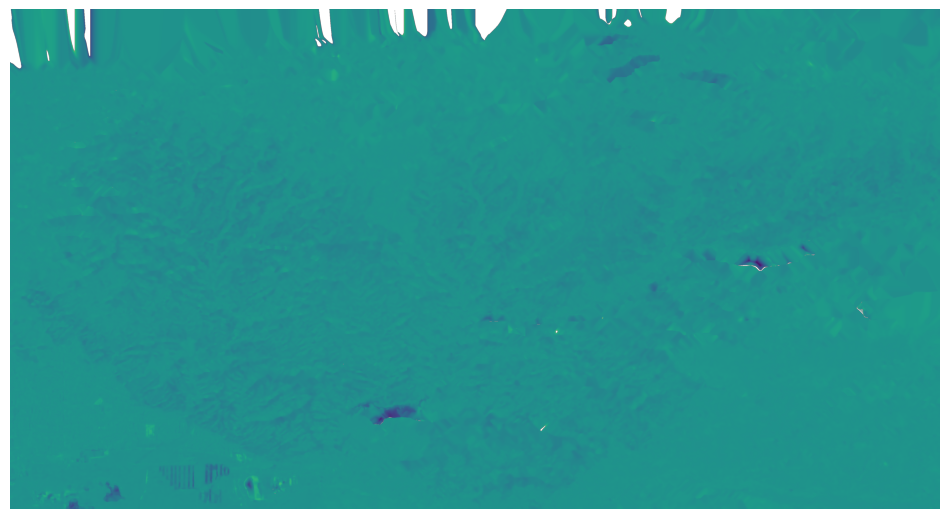

In [9]:
fig, ax = plt.subplots(figsize=(12, 10))
plt.imshow(hvhh_polarization)
plt.savefig("/hpc/home/a1/LineFireData/GradientMaps/hv_minus_hh_postpre_logratio.png")
plt.axis('off')

In [10]:
# Load if we have performed segmentation previously

superpixel_labels = np.load('/hpc/home/a1/LineFireData/SuperPixel_Labels/superpixel_labels_hh_scale1_sigma2_minsize200.npy')

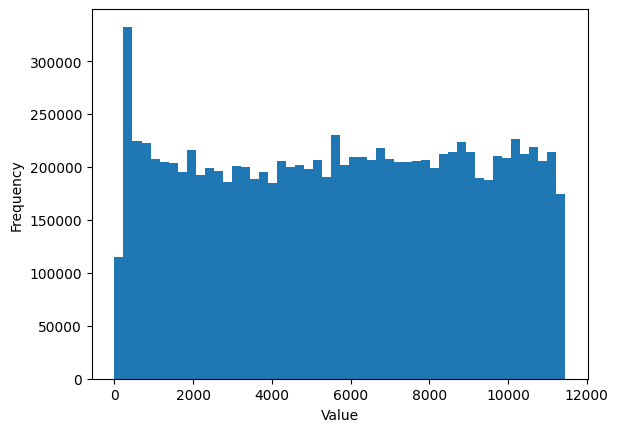

In [11]:
# Check the distribution of the data
plt.hist(superpixel_labels.flatten(), bins=50)
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.show()

## Classification

In [12]:
np.seterr(divide='ignore', invalid='ignore')
#Extracting features
mean_log_ratio = get_superpixel_means_as_features(superpixel_labels, hvhh_polarization)
std_features = get_superpixel_stds_as_features(superpixel_labels, hvhh_polarization)
# mean_slope = get_superpixel_means_as_features(superpixel_labels, slope)


In [13]:
unique_superpixel_labels = np.unique(superpixel_labels)
unique_superpixel_labels_reshape = unique_superpixel_labels.reshape(-1,1)

In [14]:
# I need to check how to make a dataframe using these columns
fire_data = np.hstack([unique_superpixel_labels_reshape,mean_log_ratio, std_features])

In [15]:
df = pd.DataFrame(fire_data, columns=['superpixel_label','mean_log_ratio','std_features'])
print(len(df))

11455


In [16]:
# Calculate the number of non-null values in each row
non_null_counts = df.count(axis=1)

# Get the total number of columns
num_columns = df.shape[1]

# Determine complete rows
complete_rows = df[non_null_counts == num_columns]

# Count the number of complete rows
num_complete_rows = len(complete_rows)
#print(num_complete_rows)

In [17]:
# retain only complete rows
df_cleaned = df.dropna()
#print(len(df_cleaned))
# pd.set_option('display.max_rows',None)
print(df_cleaned)

       superpixel_label  mean_log_ratio  std_features
2                   2.0       -1.128431      2.117031
3                   3.0       -4.527459      1.566274
4                   4.0       -5.671665      0.304224
5                   5.0       -4.302916      1.037053
6                   6.0       -3.413180      0.881320
...                 ...             ...           ...
11450           11450.0       -1.997941      0.204459
11451           11451.0        0.628254      0.561355
11452           11452.0       -1.540221      0.253863
11453           11453.0       -5.107151      2.156761
11454           11454.0        0.381639      0.357278

[11337 rows x 3 columns]


In [18]:
df_cleaned_for_model = df_cleaned.drop('superpixel_label', axis=1) # we don't want to use the superpixel label as a feature
print(df_cleaned_for_model)

       mean_log_ratio  std_features
2           -1.128431      2.117031
3           -4.527459      1.566274
4           -5.671665      0.304224
5           -4.302916      1.037053
6           -3.413180      0.881320
...               ...           ...
11450       -1.997941      0.204459
11451        0.628254      0.561355
11452       -1.540221      0.253863
11453       -5.107151      2.156761
11454        0.381639      0.357278

[11337 rows x 2 columns]


In [19]:
from sklearn.cluster import KMeans
# Selecting the K-Means model with n_clusters=2
model = KMeans(n_clusters=2, n_init=10,random_state=1)

# from sklearn.cluster import MiniBatchKMeans
# model = MiniBatchKMeans(
#     n_clusters = 2,         
#     max_iter = 200, 
#     n_init = 15
# )

In [20]:
# import time
# import threading
# def live_timer():
#     start = time.time()
#     while not done:
#         elapsed = time.time() - start
#         print(f"\rElapsed: {elapsed:.2f} sec", end="")
#         time.sleep(0.1)

# done = False
# thread = threading.Thread(target=live_timer)
# thread.start()

labeled_data = get_superpixel_model_labels(df_cleaned_for_model, model)
labeled_data = labeled_data.reshape(-1, 1)  # Ensure 2D shape
classes = get_array_from_features(superpixel_labels, labeled_data)
gdf = convert_labels_to_gdf(classes, profile)

# done = True
# thread.join()
# print("\nFinished!")

Number of unique labels: 11455
Features shape: (11337, 1)


In [21]:
classes_unique = np.unique(classes)
classes_unique

array([-1,  0,  1], dtype=int32)

In [22]:
min_area_sq_km = 0.1
top_k_index = 20

---
If the burn perimeter polygons are green instead of black swap the values in the statement,  
fire_gdf = gdf[gdf['class'] == x]  
from 0 <=> 1 depending on the case.

In [23]:
gdf = filter_by_area(gdf, min_area_sq_km)
fire_gdf = gdf[gdf['class'] == 0]
fire_gdf = fire_gdf.sort_values(by='area_sq_km', ascending=False)
fire_gdf = fire_gdf.reset_index(drop=True)
fire_gdf = fire_gdf[0:top_k_index]
#fire_gdf

In [24]:
def make_center_point(longitude, latitude):
    buffer_point = Point(longitude, latitude)
    buffer_gdf = gpd.GeoDataFrame(geometry=[buffer_point])

    return buffer_gdf

---
Generate the fire polygons and open the wildfire shapefile for comparison

- Let `fire_gdf` correspond to the fire polygon dataframe image and `pred_img` correspond to the wildfire shape image. 

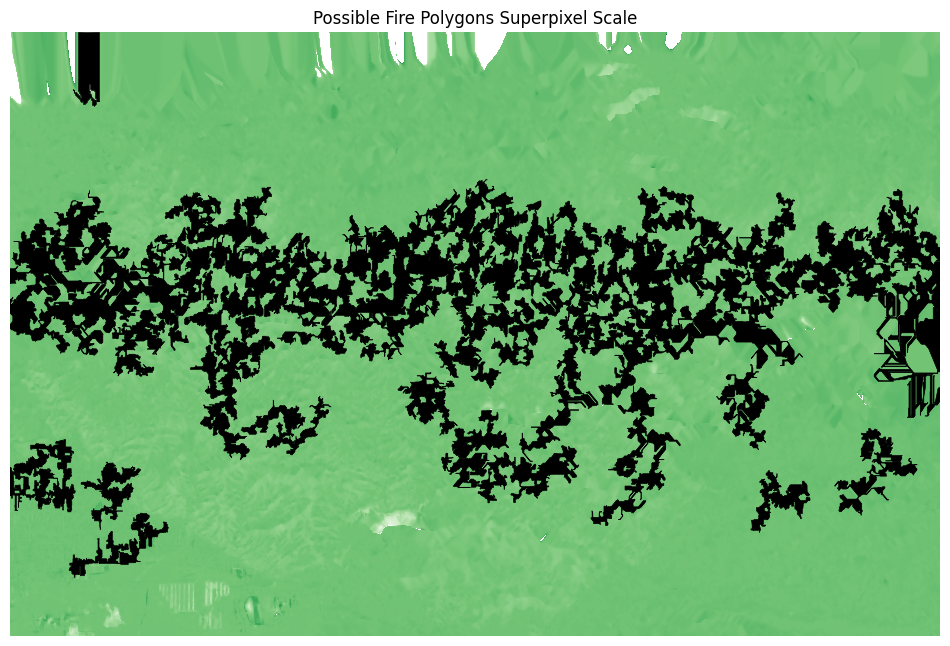

In [25]:
# Plot the GeoDataFrame on top of the log_ratio image
fig, ax = plt.subplots(figsize=(12, 10))

# Plot the log_ratio image using 'Greens' colormap for background
show(hvhh_polarization, ax=ax, transform=transform, cmap='Greens', interpolation='none')

# Plot fire polygons in solid black
fire_gdf.plot(ax=ax, facecolor="black", edgecolor="black", linewidth=0.4)

# Optional: annotate polygons
# for idx, polygon in fire_gdf.iterrows():
#     x, y = polygon.geometry.centroid.x, polygon.geometry.centroid.y
#     ax.text(x, y, str(idx), fontsize=12, color='white', ha='center', va='center')

# Plot center reference point in green (since background is green, using blue or red might improve visibility)
# make_center_point(-117.9297578, 34.332527).plot(ax=ax, color='blue', markersize=25)
plt.axis('off')
plt.title('Possible Fire Polygons Superpixel Scale')
plt.savefig("/hpc/home/a1/LineFireData/PossibleFirePolygons/KMeans/Possible_Fire_Polygons_Superpixel_scale1_sigma02_minsize200_hv_minus_hh_postpre_hhsuperpixelmap.png")
plt.show()

### --- 
Run once to get the appropriate ground truth fire perimeter afterwards it is not necessary

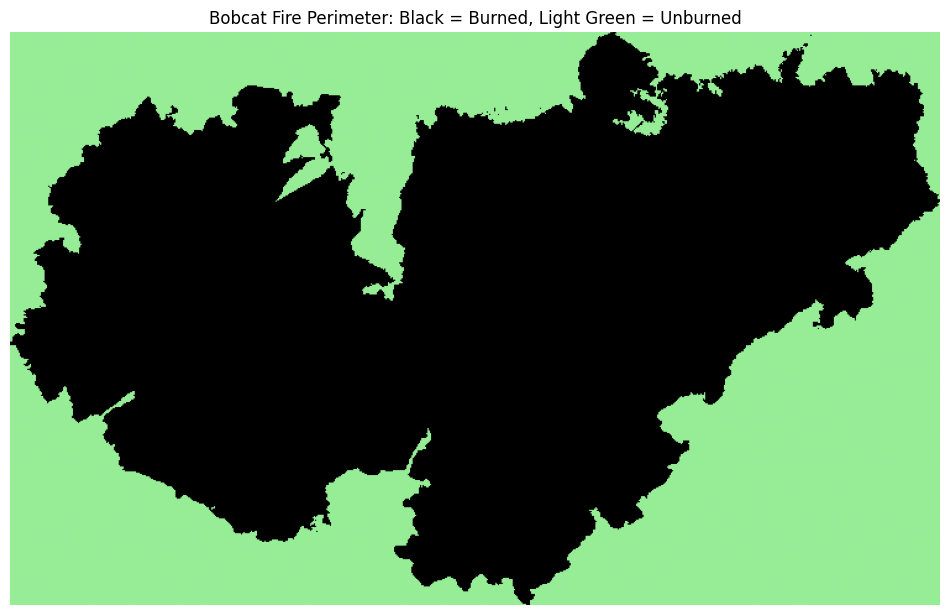

In [199]:
# Load shapefile
shapefile_path = '/hpc/home/a1/LineFireData/LineFire_Shapefile/Perimeters.shp'
perimeter = gpd.read_file(shapefile_path)

# Reproject to UTM if needed
if perimeter.crs.is_geographic:
    perimeter = perimeter.to_crs(epsg=32611)

# Raster resolution
resolution = 30

# Bounding box and raster size
minx, miny, maxx, maxy = perimeter.total_bounds
width = int((maxx - minx) / resolution)
height = int((maxy - miny) / resolution)

# Raster transform
transform = from_bounds(minx, miny, maxx, maxy, width, height)

# Rasterize: 1 inside, 0 outside
raster = rasterize(
    [(geom, 1) for geom in perimeter.geometry],
    out_shape=(height, width),
    transform=transform,
    fill=0,
    dtype='uint8'
)

# Define custom colormap: light green (0), black (1)
light_green = '#96ed96'  # soft/light green
black = '#000000'
cmap = ListedColormap([light_green, black])

# Display
plt.figure(figsize=(12, 10))
plt.imshow(raster, cmap=cmap, origin='upper')
plt.title("Bobcat Fire Perimeter: Black = Burned, Light Green = Unburned")
plt.axis('off')
plt.savefig("/hpc/home/a1/BobcatWildfireData/SavedOutputs/BobcatFirePerimeter/LineFire Perimeter:Black Burned, Light Green Unburned.png")
plt.show()

In [30]:
# === Load ground truth and prediction images ===
gt_img = Image.open("/hpc/home/a1/BobcatWildfireData/SavedOutputs/BobcatFirePerimeter/BobcatWildfire_Ground_Truthx.png").convert('L')
pred_img = Image.open('/hpc/home/a1/BobcatWildfireData/SavedOutputs/Possible_Fire_Polygons_Superpixel_minsize50_apc_defaultsx.png').convert('L')

# === Resize prediction to match ground truth ===
pred_img_resized = pred_img.resize(gt_img.size, Image.NEAREST)

# Convert to numpy arrays
gt_array = np.array(gt_img)
pred_array = np.array(pred_img_resized)

# === Convert to binary masks (0 = unburned, 1 = burned) ===
gt_mask = (gt_array > 128).astype(np.uint8)
pred_mask = (pred_array > 128).astype(np.uint8)

# === Flatten for confusion matrix ===
y_true = gt_mask.flatten()
y_pred = pred_mask.flatten()

# === Compute confusion matrix (counts and percentages) ===
cm = confusion_matrix(y_true, y_pred, labels=[1, 0])
cm_percent = cm / cm.sum() * 100
labels = ['Burned (Black)', 'Unburned (Green)']

# === Compute accuracy and other metrics ===
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

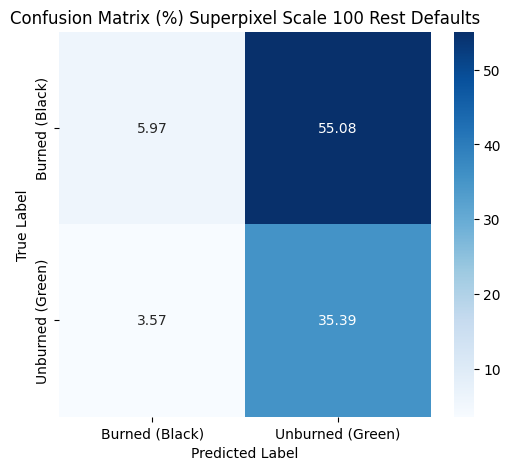


 Classification Metrics:
Accuracy : 0.4135
Precision: 0.6259
Recall   : 0.0978
F1-score : 0.1691


In [32]:
# === Plot heatmap (percentages) ===
plt.figure(figsize=(6, 5))
sns.heatmap(cm_percent, annot=True, fmt='.2f', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (%) Superpixel Scale 100 Rest Defaults')
plt.savefig("/hpc/home/a1/BobcatWildfireData/SavedOutputs/ConfusionMatrices/Confusion Matrix (%) Superpixel_scale100_rest_defaults.png")
plt.show()
print("\n Classification Metrics:")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")